In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.research_config import ResearchConfig
from src.data_helpers import write_json
from src.research_validation import aligned_returns
from src.research_validation import market_regression
from src.data_helpers import read_series
from src.research_validation import bootstrap_mean
from src.backtest import run_walk_forward_backtest
from src.data_helpers import backtest_kwargs
from src.research_validation import placebo_samples
from src.research_validation import portfolio_metrics
from src.research_validation import compare_placebos


# 12 Alpha Validation

Evaluate the saved portfolio using the same benchmark alignment as Module 09, a raw-mean bootstrap and matched portfolio placebos. The main portfolio is not rerun. Only the placebo portfolios are newly simulated here.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


In [ ]:
cfg = ResearchConfig().validate()


## 2. Market adjusted alpha

This uses the same shared regression function, benchmark, rates and HAC convention as Module 09.


In [2]:
aligned = aligned_returns(
    pd.read_parquet("equity_curve.parquet"),
    read_series("data/inputs/sp500_prices.parquet"),
    read_series("data/inputs/risk_free_rates.parquet"),
)
aligned.to_parquet("market_alignment.parquet")
market_alpha = market_regression(aligned, cfg.hac_lags)
write_json("market_alpha.json", market_alpha)
display(pd.Series(market_alpha))


status                                                       ok
alpha_daily                                            0.000497
alpha_annualized_simple                                0.125291
alpha_HAC_se                                           0.001058
alpha_t_stat                                           0.469916
alpha_p_value_two_sided                                0.638415
alpha_p_value_one_sided_positive                       0.319207
market_beta                                           -0.135836
r_squared                                              0.002611
n_obs                                                       754
hac_lags                                                      5
rf_convention                       annual_effective_lagged_252
start                                       2022-12-29 00:00:00
end                                         2025-12-31 00:00:00
dtype: object

## 3. Moving block bootstrap

Bootstrap intervals estimate the unconditional raw daily mean, not market-adjusted alpha. Report all configured block lengths.


In [3]:
bootstrap = bootstrap_mean(
    aligned.strategy_return, cfg.bootstrap_blocks, cfg.bootstrap_replications, cfg.seed
)
bootstrap.to_csv("bootstrap_mean.csv", index=False)
display(bootstrap)


,block_length,status,n_replications,observed_mean,ci_low,ci_high,estimand
0,10,ok,10000,0.000591,-0.001433,0.002671,unconditional_mean_raw_daily_return
1,20,ok,10000,0.000591,-0.001321,0.002524,unconditional_mean_raw_daily_return
2,40,ok,10000,0.000591,-0.001266,0.002269,unconditional_mean_raw_daily_return


## 4. Matched pair selection placebos

This is the long-running cell: 100 portfolios by default. It uses the same finite-horizon pool, portfolio size, entry order, costs and cash rules as the actual portfolio. Each execution recalculates all draws and overwrites the previous placebo results. No saved checkpoints are reused.


In [ ]:
def load_backtest(c, pairs=None, signal_cache=None):
    rd = lambda name: pd.read_parquet(name + ".parquet")
    return run_walk_forward_backtest(
        rd("train_prices"),
        rd("test_prices"),
        rd("eligible_pairs") if pairs is None else pairs,
        rd("cointegrated_pairs"),
        read_series("data/inputs/risk_free_rates.parquet"),
        signal_cache=signal_cache,
        **backtest_kwargs(c),
    )


def validate_placebos(c):
    pool = pd.read_parquet("eligible_pool.parquet")
    top = pd.read_parquet("eligible_pairs.parquet")
    actual = json.loads(open("backtest_summary.json").read())
    rows = []
    signal_cache = {}
    for j, sample in placebo_samples(pool, len(top), c.n_placebos, c.seed):
        pairs = sample.pair.tolist()
        row = {
            **portfolio_metrics(
                load_backtest(c, sample, signal_cache), c.initial_capital
            ),
            "placebo_id": j,
            "sampled_pairs": pairs,
            "seed": c.seed,
        }
        write_json(f"placebo_{j:04d}.json", row)
        rows.append(row)
        print(f"Placebo {j + 1}/{c.n_placebos} completed", flush=True)
    frame = pd.DataFrame(rows)
    frame.to_parquet("placebos.parquet")
    compare_placebos(actual, frame).to_csv("placebo_comparison.csv", index=False)
    write_json(
        "placebo_design.json",
        {
            "null": "uniform subsets of finite-structural-horizon pool",
            "pool_size": len(pool),
            "portfolio_size": len(top),
            "n_draws": c.n_placebos,
            "duplicate_draws_allowed": True,
            "degenerate_membership_null": len(pool) == len(top),
            "execution_order": "alphabetical pair ID for baseline and every placebo",
            "scope": "conditional descriptive reference; does not adjust all research specification searches",
        },
    )


In [4]:
print(f"Running {cfg.n_placebos} placebo portfolios; all draws will be recalculated.")
validate_placebos(cfg)
placebos = pd.read_parquet("placebos.parquet")
display(placebos.head())


Running 100 placebo portfolios; all draws will be recalculated.


Placebo 1/100 completed


Placebo 2/100 completed


Placebo 3/100 completed


Placebo 4/100 completed


...

Placebo 97/100 completed


Placebo 98/100 completed


Placebo 99/100 completed


Placebo 100/100 completed


,initial_capital,final_equity,total_return,max_drawdown,n_trades,win_rate,average_trade_return,median_trade_return,max_concurrent_positions,daily_sharpe,placebo_id,sampled_pairs,seed
0,100000.0,102042.452215,0.020425,-0.476588,102.0,0.539216,0.023125,0.095596,17.0,0.161314,0,"[AAPL-MPWR, ABT-STE, ABT-ZTS, ADBE-DPZ, ADI-TX...",42
1,100000.0,110201.710099,0.102017,-0.625611,114.0,0.500000,0.056905,0.027343,20.0,0.262295,1,"[A-MTD, AAPL-MPWR, ABT-ZTS, ADI-TXN, ADP-MSI, ...",42
2,100000.0,141068.210747,0.410682,-0.441730,112.0,0.562500,0.104262,0.189340,17.0,0.538452,2,"[A-MTD, AAPL-MPWR, ABT-STE, ABT-ZTS, ADBE-DPZ,...",42
3,100000.0,112273.931589,0.122739,-0.264234,89.0,0.573034,0.048235,0.118556,15.0,0.277586,3,"[ABT-STE, ADBE-DPZ, ADI-TXN, AMAT-MCHP, AMZN-C...",42
4,100000.0,146545.885963,0.465459,-0.311369,105.0,0.561905,0.100521,0.120817,19.0,0.587931,4,"[A-MTD, ABT-STE, ADBE-DPZ, ADI-TXN, ADP-MSI, A...",42


## 5. Comparison and interpretation

The finite-sample upper-tail comparison includes ties. This is a conditional reference comparison, not proof of a trading edge or a correction for every research choice.


,metric,status,actual,n_draws,p_value,percentile
0,total_return,ok,0.236138,100,0.623762,38.0
1,daily_sharpe,ok,0.371287,100,0.623762,38.0
2,average_trade_return,ok,0.042065,100,0.782178,22.0


null                          uniform subsets of finite-structural-horizon pool
pool_size                                                                    57
portfolio_size                                                               40
n_draws                                                                     100
duplicate_draws_allowed                                                    True
degenerate_membership_null                                                False
execution_order               alphabetical pair ID for baseline and every pl...
scope                         conditional descriptive reference; does not ad...
dtype: object

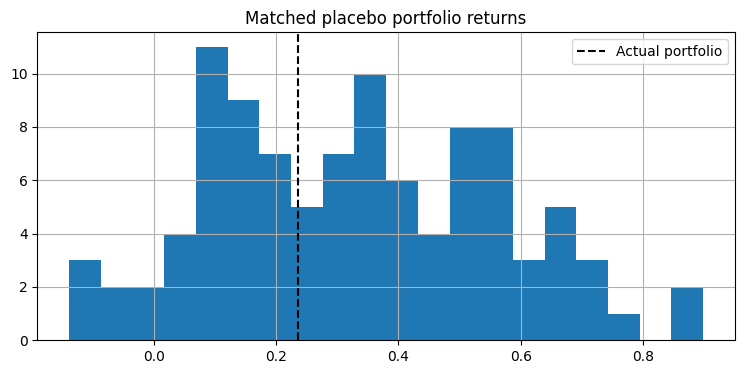

Results ready for review: /home/runner/work/Pairs_trading/Pairs_trading/data/processed/current


In [5]:
comparison = pd.read_csv("placebo_comparison.csv")
design = json.loads(open("placebo_design.json").read())
display(comparison)
display(pd.Series(design))
if not placebos.empty:
    actual = json.loads(open("backtest_summary.json").read())
    placebos.total_return.hist(bins=20, figsize=(9, 4))
    plt.axvline(
        actual["total_return"], color="black", linestyle="--", label="Actual portfolio"
    )
    plt.title("Matched placebo portfolio returns")
    plt.legend()
    plt.show()


## Save module completion

Wait for this confirmation before moving to the next notebook.
